In [8]:
import pandas as pd
import numpy as np
import torch
import torchvision
import xgboost
import sklearn
import matplotlib
from PIL import Image
print("全部依赖导入成功！")

全部依赖导入成功！


In [9]:
import pandas as pd

# 载入本地csv数据
df = pd.read_csv("glaucoma_train.csv")

# 预览前5行
print(df.head())
print("\n字段信息：")
print(df.dtypes)

                                               image  label  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      1   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   

                  filename annotation  \
0   acrima_glaucoma_57.png   glaucoma   
1   acrima_normal_1058.png     normal   
2  acrima_glaucoma_188.png   glaucoma   
3  acrima_glaucoma_182.png   glaucoma   
4   acrima_glaucoma_21.png   glaucoma   

                                         description  
0  {\n    "fundus_features": {\n        "optic_di...  
1  {\n    "fundus_features": {\n        "optic_di...  
2  {\n    "fundus_features": {\n        "optic_di...  
3  {\n    "fundus_features": {\n        "optic_di...  
4  {\n    "fundus_features": {\n        "optic_di...  

字段信息：
image          object
label          

In [10]:
print("变量个数：", len(df.columns))
print("变量名称：", df.columns.tolist())

变量个数： 5
变量名称： ['image', 'label', 'filename', 'annotation', 'description']


In [11]:
import json

desc = df['description'].iloc[0]
desc_dict = json.loads(desc)
print(json.dumps(desc_dict, indent=2, ensure_ascii=False))

{
  "fundus_features": {
    "optic_disc_size": "large",
    "cup_to_disc_ratio": 0.8,
    "neuroretinal_rim": "thinned in all regions, especially inferior and superior",
    "isnt_rule_followed": false,
    "rim_pallor": true,
    "rim_color": "pale",
    "bayoneting": true,
    "sharp_edge": true,
    "laminar_dot_sign": true,
    "notching": true,
    "rim_thinning": true,
    "additional_observations": null
  },
  "glaucoma_risk_assessment": "high risk",
  "confidence_level": 0.9
}


In [12]:
import pandas as pd
import json

# 假设你的原始 DataFrame 名为 df
def flatten_description(row):
    try:
        desc = json.loads(row['description'])
        flat = {}
        # 1. 外层直接变量
        if 'glaucoma_risk_assessment' in desc:
            flat['glaucoma_risk_assessment'] = desc['glaucoma_risk_assessment']
        if 'confidence_level' in desc:
            flat['confidence_level'] = desc['confidence_level']
        # 2. fundus_features 展开
        ff = desc.get('fundus_features', {})
        for k, v in ff.items():
            flat[k] = v
        return pd.Series(flat)
    except Exception as e:
        # print(f"Error parsing: {e}")
        return pd.Series()

# 应用展开
desc_df = df.apply(flatten_description, axis=1)

# 拼回原表
df_new = pd.concat([df, desc_df], axis=1)

print("新变量（列）如下：")
print(df_new.columns.tolist())
print(df_new.head())

新变量（列）如下：
['image', 'label', 'filename', 'annotation', 'description', 'glaucoma_risk_assessment', 'confidence_level', 'optic_disc_size', 'cup_to_disc_ratio', 'neuroretinal_rim', 'isnt_rule_followed', 'rim_pallor', 'rim_color', 'bayoneting', 'sharp_edge', 'laminar_dot_sign', 'notching', 'rim_thinning', 'additional_observations']
                                               image  label  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      1   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   

                  filename annotation  \
0   acrima_glaucoma_57.png   glaucoma   
1   acrima_normal_1058.png     normal   
2  acrima_glaucoma_188.png   glaucoma   
3  acrima_glaucoma_182.png   glaucoma   
4   acrima_glaucoma_21.png   glaucoma   

                                         des

In [13]:
# 展示处理后的数据集前几行
print(df_new.head())

# 展示所有变量（列）名称
print("变量个数：", len(df_new.columns))
print("变量名称：", df_new.columns.tolist())


                                               image  label  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      1   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   

                  filename annotation  \
0   acrima_glaucoma_57.png   glaucoma   
1   acrima_normal_1058.png     normal   
2  acrima_glaucoma_188.png   glaucoma   
3  acrima_glaucoma_182.png   glaucoma   
4   acrima_glaucoma_21.png   glaucoma   

                                         description glaucoma_risk_assessment  \
0  {\n    "fundus_features": {\n        "optic_di...                high risk   
1  {\n    "fundus_features": {\n        "optic_di...             very healthy   
2  {\n    "fundus_features": {\n        "optic_di...                high risk   
3  {\n    "fundus_features": {\n        "optic_di.

In [14]:
# 删除原始的 description 字段（保留其它所有字段，包括展开出来的新医学特征）
df_new = df_new.drop(columns=['description'])

# 查看新表结构确认
print(df_new.columns)
print(df_new.head())

Index(['image', 'label', 'filename', 'annotation', 'glaucoma_risk_assessment',
       'confidence_level', 'optic_disc_size', 'cup_to_disc_ratio',
       'neuroretinal_rim', 'isnt_rule_followed', 'rim_pallor', 'rim_color',
       'bayoneting', 'sharp_edge', 'laminar_dot_sign', 'notching',
       'rim_thinning', 'additional_observations'],
      dtype='object')
                                               image  label  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      1   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   

                  filename annotation glaucoma_risk_assessment  \
0   acrima_glaucoma_57.png   glaucoma                high risk   
1   acrima_normal_1058.png     normal             very healthy   
2  acrima_glaucoma_188.png   glaucoma                high ris

In [15]:
print(df_new.head())

print("\n当前变量（列）名称：")
print(df_new.columns.tolist())

print("\n变量总数：", len(df_new.columns))

                                               image  label  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      1   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...      0   

                  filename annotation glaucoma_risk_assessment  \
0   acrima_glaucoma_57.png   glaucoma                high risk   
1   acrima_normal_1058.png     normal             very healthy   
2  acrima_glaucoma_188.png   glaucoma                high risk   
3  acrima_glaucoma_182.png   glaucoma                high risk   
4   acrima_glaucoma_21.png   glaucoma                high risk   

   confidence_level optic_disc_size  cup_to_disc_ratio  \
0              0.90           large                0.8   
1              0.95          normal                0.4   
2              0.90          normal               

In [16]:
# 假设医学特征和 label 已经在 df_new
# 通常我们只需要 label + description 展开后的新变量
cols_to_use = [col for col in df_new.columns if col != 'image' and col != 'filename' and col != 'annotation']
X = df_new[cols_to_use].drop(columns=['label'])   # 所有特征
y = df_new['label']                               # 标签

In [17]:
X_encoded = pd.get_dummies(X, dummy_na=True)  # 自动 one-hot 所有 object 类型变量

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [19]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

model = xgb.XGBClassifier(
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss",
    n_estimators=100,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")
print("\n分类报告：")
print(classification_report(y_val, y_pred))

[0]	validation_0-logloss:0.39896
[1]	validation_0-logloss:0.27216
[2]	validation_0-logloss:0.19214
[3]	validation_0-logloss:0.13837
[4]	validation_0-logloss:0.10101
[5]	validation_0-logloss:0.07452
[6]	validation_0-logloss:0.05547
[7]	validation_0-logloss:0.04164
[8]	validation_0-logloss:0.03154
[9]	validation_0-logloss:0.02411
[10]	validation_0-logloss:0.01863
[11]	validation_0-logloss:0.01455
[12]	validation_0-logloss:0.01151
[13]	validation_0-logloss:0.00923
[14]	validation_0-logloss:0.00751
[15]	validation_0-logloss:0.00619
[16]	validation_0-logloss:0.00517
[17]	validation_0-logloss:0.00438
[18]	validation_0-logloss:0.00375
[19]	validation_0-logloss:0.00375
[20]	validation_0-logloss:0.00375
[21]	validation_0-logloss:0.00375
[22]	validation_0-logloss:0.00375
[23]	validation_0-logloss:0.00375
[24]	validation_0-logloss:0.00375
[25]	validation_0-logloss:0.00375
[26]	validation_0-logloss:0.00375
[27]	validation_0-logloss:0.00375
[28]	validation_0-logloss:0.00375
[29]	validation_0-loglos

/opt/anaconda3/envs/xgb/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:24:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Top 10重要特征：
                                                feature  importance
1                                    cup_to_disc_ratio         1.0
156  neuroretinal_rim_Thickness appears normal in a...         0.0
144  neuroretinal_rim_Thick neuroretinal rim in sup...         0.0
145  neuroretinal_rim_Thick neuroretinal rim observ...         0.0
146  neuroretinal_rim_Thick rim superiorly, inferio...         0.0
147  neuroretinal_rim_Thick superior and inferior r...         0.0
148  neuroretinal_rim_Thick superiorly and inferior...         0.0
149  neuroretinal_rim_Thick superiorly and inferior...         0.0
150  neuroretinal_rim_Thick superiorly and inferior...         0.0
151  neuroretinal_rim_Thick superiorly, thick infer...         0.0


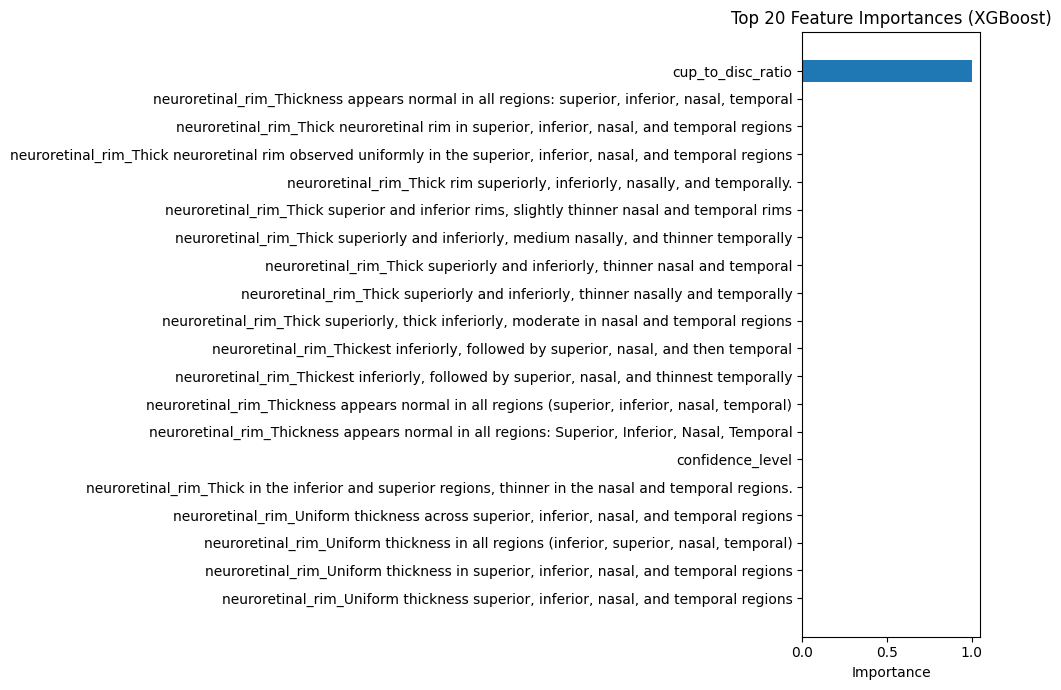

In [20]:
import matplotlib.pyplot as plt
importances = model.feature_importances_
imp_df = pd.DataFrame({'feature': X_encoded.columns, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

print("\nTop 10重要特征：\n", imp_df.head(10))

plt.figure(figsize=(10,7))
plt.barh(imp_df.head(20)['feature'][::-1], imp_df.head(20)['importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()